# TechnoStamp - análisis integral


In [9]:
from pathlib import Path
import subprocess
import sys
from IPython.display import Image, display

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "03_notebooks" else NOTEBOOK_DIR
SCRIPTS_DIR = PROJECT_ROOT / "04_scripts"
VISUALIZACIONES_DIR = PROJECT_ROOT / "06_resultados" / "Discovery" / "visualizaciones"

if not SCRIPTS_DIR.exists():
    raise FileNotFoundError(f"No se encontro la carpeta de scripts: {SCRIPTS_DIR}")

def _mostrar_salida(texto: str, stream) -> None:
    if texto:
        print(texto, end="" if texto.endswith("\n") else "\n", file=stream)

def mostrar_graficos(nombres: list[str], width: int = 1100) -> None:
    for nombre in nombres:
        imagen = VISUALIZACIONES_DIR / nombre
        if not imagen.exists():
            raise FileNotFoundError(f"No se encontro el grafico: {imagen}")
        display(Image(filename=str(imagen), width=width))


def ejecutar_etapa(nombre_script: str) -> None:
    script = SCRIPTS_DIR / nombre_script

    if not script.exists():
        raise FileNotFoundError(f"No existe el script: {script}")

    ejecutor = "\n".join([
        "import pandas as pd, runpy, sys",
        "pd.set_option('display.float_format', lambda x: format(x, ',.10f').rstrip('0').rstrip('.'))",
        "runpy.run_path(sys.argv[1], run_name='__main__')",
    ])
    resultado = subprocess.run(
        [sys.executable, "-c", ejecutor, str(script)],
        cwd=PROJECT_ROOT,
        text=True,
        encoding="utf-8",
        errors="strict",
        capture_output=True,
        check=False,
    )

    _mostrar_salida(resultado.stdout, sys.stdout)
    _mostrar_salida(resultado.stderr, sys.stderr)

    if resultado.returncode != 0:
        raise subprocess.CalledProcessError(
            resultado.returncode,
            resultado.args,
            output=resultado.stdout,
            stderr=resultado.stderr,
        )

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Scripts: {SCRIPTS_DIR}")


Proyecto: C:\Users\Dell\Agus\Nivii AI
Scripts: C:\Users\Dell\Agus\Nivii AI\04_scripts


## 1. Perfilado inicial

Datos generales del personal estan completos, pero las métricas de produccción tienen muchos nulos. Decidí no imputarlos automáticamente porque todos necesitan una explicacion relacionada al negocio. No se eliminaron filas ni modificaron valores extremos, nomas se marcaron para revisarlas bien.

**Script ejecutado:** `04_scripts/01_perfilado.py`
Los eventos de RR. HH. y las capacitaciones complementan la información sobre movimientos, incidentes y desarrollo del personal.

In [10]:
ejecutar_etapa("01_perfilado.py")


TABLA: empleados_mensual   shape=(9733, 47)
------------------------------------------------------------------------------------------
                                dtype  n_nulos  pct_nulos  n_unicos               ejemplo
empleado_id                     int64        0          0       694                  1000
mes_snapshot                      str        0          0        17            2024-01-01
activo                           bool        0          0         2                  True
nombre                            str        0          0       596         Teresa Carmen
genero                            str        0          0         2                     F
edad                            int64        0          0        41                    62
fecha_nacimiento                  str        0          0       127            1962-06-15
fecha_ingreso                     str        0          0       103            2012-01-01
antiguedad_meses                int64        0         

## 2. Calidad de datos

Tiene que leerse en UTF-8 para evitar caracteres raros.
Se detectaron inconsistencias en 51 edades, 483 antigüedades y 71 registros anteriores al ingreso. Se las marcó para revisarlas. Los salarios altos (numéricamente outliers) tienen coherencia con cargos mas altos, por eso no los elimino.
Se unificaron categorías como “Técnica/Técnico”, “Mixta/Mixto” y “high/Grave”;

**Script ejecutado:** `04_scripts/02_calidad.py`


In [11]:
ejecutar_etapa("02_calidad.py")


### 1. ENCODING
  utf-8      OK -> puesto ejemplo: 'Técnico Setup'
  latin-1    OK -> puesto ejemplo: 'TÃ©cnico Setup'
  cp1252     FALLA: UnicodeDecodeError

### 2. GRANULARIDAD empleados_mensual
  filas: 9733 | empleados unicos: 694 | meses: 17
  duplicados (empleado_id, mes_snapshot): 0
  rango meses: 2024-01-01 -> 2025-05-01

  headcount ACTIVO por mes:
              filas  activos
mes_snapshot                
2024-01-01      605      586
2024-02-01      587      587
2024-03-01      591      574
2024-04-01      577      568
2024-05-01      572      567
2024-06-01      571      564
2024-07-01      570      566
2024-08-01      572      562
2024-09-01      566      560
2024-10-01      565      562
2024-11-01      567      563
2024-12-01      566      552
2025-01-01      558      554
2025-02-01      560      553
2025-03-01      563      559
2025-04-01      577      562
2025-05-01      566      562

### 3. CONSISTENCIA INTERNA
  edad declarada vs calculada -> dif abs >1 anio: 51
  antig

## 3. Limpieza y preparación 

Normaliza nombres y tipos (acentos y eñes), documenta por qué faltan datos y marca inconsistencias sin borrar información. 
**Script ejecutado:** `04_scripts/13_limpieza_v2.py`


In [12]:
ejecutar_etapa("13_limpieza_v2.py")


Carga OK — empleados (9733, 47) | eventos (8705, 18) | capacitaciones (729, 17)

MEJORA 3 — nombres de columna sin eñes ni acentos
  [renombrar_columna] {'tabla': 'empleados', 'de': 'años_en_puesto_actual', 'a': 'anios_en_puesto_actual'}
  [renombrar_columna] {'tabla': 'empleados', 'de': 'horas_training_acumulado_año', 'a': 'horas_training_acumulado_anio'}
  Nombres finales verificados como unicos en las 3 tablas

MEJORA 4 — tipos correctos
  [a_fecha] {'tabla': 'empleados', 'col': 'mes_snapshot'}
  [a_fecha] {'tabla': 'empleados', 'col': 'fecha_nacimiento'}
  [a_fecha] {'tabla': 'empleados', 'col': 'fecha_ingreso'}
  [a_fecha] {'tabla': 'empleados', 'col': 'fecha_salida'}
  [a_fecha] {'tabla': 'empleados', 'col': 'ultimo_training_fecha'}
  [a_fecha] {'tabla': 'eventos', 'col': 'fecha_evento'}
  [a_fecha] {'tabla': 'capacitaciones', 'col': 'fecha_inicio'}
  [a_fecha] {'tabla': 'capacitaciones', 'col': 'fecha_fin'}
  [a_entero_con_vacios] {'tabla': 'empleados', 'col': 'manager_id', 'dec

## 4. P1 y P2 - sucesión y equidad

Calcula el riesgo de sucesión por puesto y describe la distribución de género por área y nivel. Ayuda a encontrar posiciones críticas y posibles brechas.

**Script ejecutado:** `04_scripts/04_p1_p2.py`


In [13]:
ejecutar_etapa("04_p1_p2.py")


Universo de analisis: 562 empleados ACTIVOS a 2025-05-01

P1 — RIESGO DE SUCESION / JUBILACION
Criterio activo de criticidad: indice propio (score_crit >= 2); es_posicion_critica se conserva solo para auditoria.

Jubilaciones proximas (sobre 562 activos):
  <= 12 meses   :   4 empleados ( 0.7%) | de ellos criticos por indice: 1
  <= 24 meses   :   4 empleados ( 0.7%) | de ellos criticos por indice: 1
  <= 36 meses   :   4 empleados ( 0.7%) | de ellos criticos por indice: 1
  <= 60 meses   :   4 empleados ( 0.7%) | de ellos criticos por indice: 1

Posiciones con criticidad estimada activa: 47 (8.4% de la dotacion)

--- Criticidad estimada que se jubila en <=12m, por area y puesto ---
                                   n  edad_prom  antig_anios  meses_rest              salario
area      puesto                                                                             
Logística Supervisor de Logística  1         64          4.3           6 3,486,692.6000000001

  TOTAL con criticidad es

C:\Users\Dell\Agus\Nivii AI\04_scripts\04_p1_p2.py:64: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  g["total"]=g.sum(1); g["pct_F"]=(g.get("F",0)/g.total*100).round(1)
C:\Users\Dell\Agus\Nivii AI\04_scripts\04_p1_p2.py:70: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  n["total"]=n.sum(1); n["pct_F"]=(n.get("F",0)/n.total*100).round(1)


## 5. Verificación de posiciones críticas

Contrasta dotación reducida, roles de liderazgo y antigüedad. Así no se llama crítico a un puesto por una sola señal aislada.

**Script ejecutado:** `04_scripts/05_verif_critica.py`


In [14]:
ejecutar_etapa("05_verif_critica.py")


### es_posicion_critica
  filas panel con critica=True: 152
  empleados que ALGUNA VEZ fueron criticos: 10
  empleados criticos en su ULTIMO snapshot: 10
  varia dentro del mismo empleado?: 0 empleados

  Quienes son los criticos (activos):
 empleado_id                    area                  puesto  nivel_jerarquico  edad  antiguedad_anios  span_of_control  meses_hasta_jubilacion
        1098               Estampado           Técnico Setup                 1    64              11.3                0                       6
        1484 Mantenimiento Eléctrico          Instrumentista                 1    58               6.4                0                      66
        1542               Logística   Team Leader Logística                 2    62               6.3                1                      12
        1544               Logística   Team Leader Logística                 2    63               4.3                2                       9
        1547               Logística Su

## 6. carga, seguridad y rotación

Genera indicadores de horas extra, sobrecarga, incidentes y rotación. Estos indicadores conectan bienestar operativo y riesgo de salida.

**Script ejecutado:** `04_scripts/06_p3_p4_p5.py`


In [15]:
ejecutar_etapa("06_p3_p4_p5.py")


P3 - HORAS EXTRA: CONCENTRACION Y COSTO

Costo TOTAL horas extra (17 meses): $1,399,111,105 | sobre nomina base: 8.3%
Costo HE anualizado (12m): $987,607,839

--- Pareto: concentracion del costo de HE por empleado ---
  Top    5% empleados ( 33 pers.) concentran 10.7% del costo de HE
  Top   10% empleados ( 67 pers.) concentran 19.5% del costo de HE
  Top   20% empleados (135 pers.) concentran 34.6% del costo de HE
  Top   30% empleados (202 pers.) concentran 47.6% del costo de HE

--- HE por AREA (promedio mensual por empleado) ---
                         emp  he_prom_mes  he_p90  pct_he_nomina               costo_he  costo_he_anual
area                                                                                                   
Mantenimiento Eléctrico   46        12.06   18.12          10.28  99,955,317.4300000072      70,556,695
Pintura                   80        11.92    16.5          10.16 204,050,231.7100000083     144,035,458
Logística                 35         11.5    

## 7. Verificación de incidentes y capacitación

Cruza información a nivel empleado-mes y compara fuentes. Es una auditoría para comprobar que los incidentes y la relación con capacitación son trazables.

**Script ejecutado:** `04_scripts/07_verif_incidentes_p5.py`


In [16]:
ejecutar_etapa("07_verif_incidentes_p5.py")


### DISCREPANCIA ENTRE FUENTES DE INCIDENTES
            eventos_rrhh  panel_count  dif
2024-01-01             3            3    0
2024-02-01             0            3    3
2024-03-01             4            5    1
2024-04-01             2            4    2
2024-05-01             3            5    2
2024-06-01             3            4    1
2024-07-01             2            6    4
2024-08-01             6            8    2
2024-09-01             5           10    5
2024-10-01             1            6    5
2024-11-01             3            6    3
2024-12-01             3            4    1
2025-01-01             1            5    4
2025-02-01             1            7    6
2025-03-01             3           10    7
2025-04-01             3            6    3
2025-05-01             2            8    6

  TOTAL eventos_rrhh: 45 | TOTAL panel (suma columna): 100
  Empleados-mes con count>1: 1 | max valor: 2
  Empleado-mes con evento registrado: 45
  Empleado-mes con count>0 en pane

C:\Users\Dell\Agus\Nivii AI\04_scripts\07_verif_incidentes_p5.py:20: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  cmp = pd.concat([a, b], axis=1).fillna(0).astype(int)


## 8. Visualizaciones

Construye los gráficos de personas, equidad, carga, seguridad, rotación y trazabilidad a partir de los resultados de las etapas anteriores.

**Script ejecutado:** `04_scripts/08_visualizaciones.py`


  -> G1_piramide_etaria.png
  -> G2_genero_area_y_nivel.png
  -> G3_brecha_salarial.png
  -> G4_horas_extra.png
  -> G5_seguridad.png
  -> G6_rotacion.png
  -> G7_brecha_trazabilidad.png

Listo. Visualizaciones en: C:\Users\Dell\Agus\Nivii AI\06_resultados\Discovery\visualizaciones


C:\Users\Dell\Agus\Nivii AI\04_scripts\08_visualizaciones.py:51: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  g["pct_F"] = (g.get("F", 0) / g.sum(1) * 100).round(1)
C:\Users\Dell\Agus\Nivii AI\04_scripts\08_visualizaciones.py:61: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  n["pct_F"] = (n.get("F", 0) / n.sum(1) * 100).round(1)


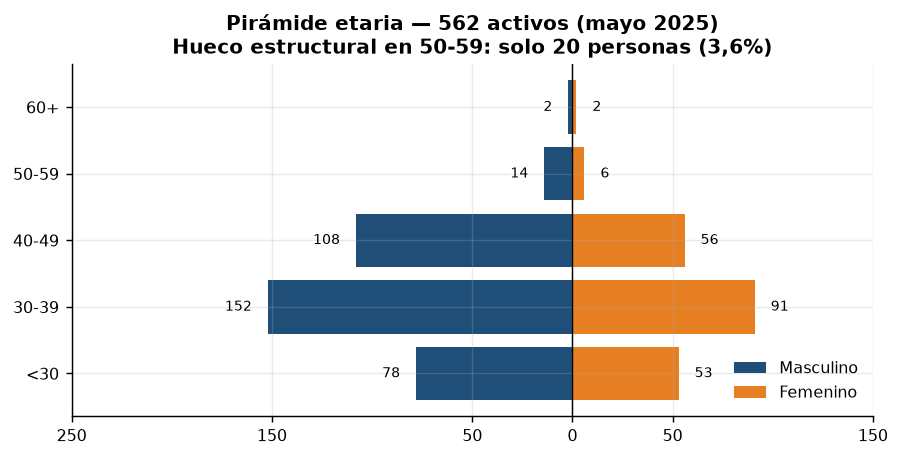

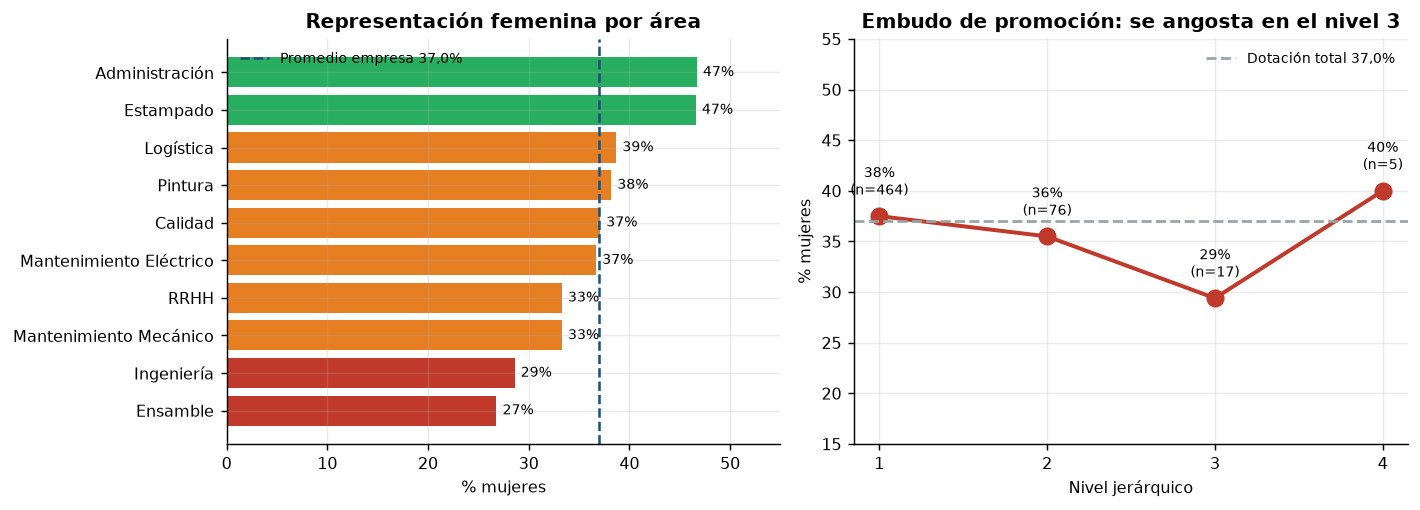

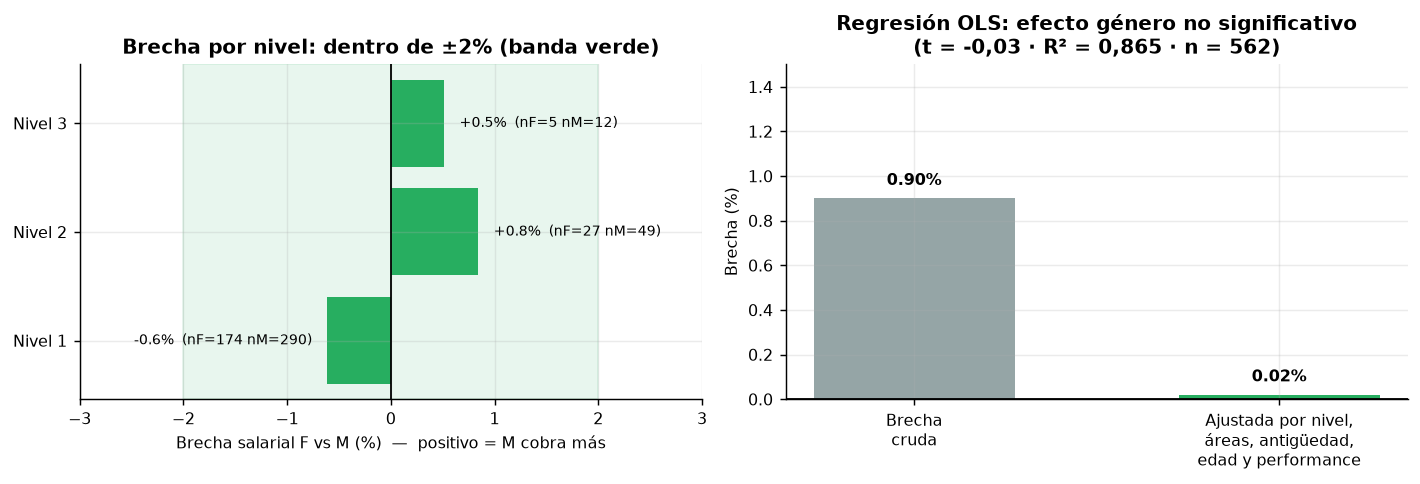

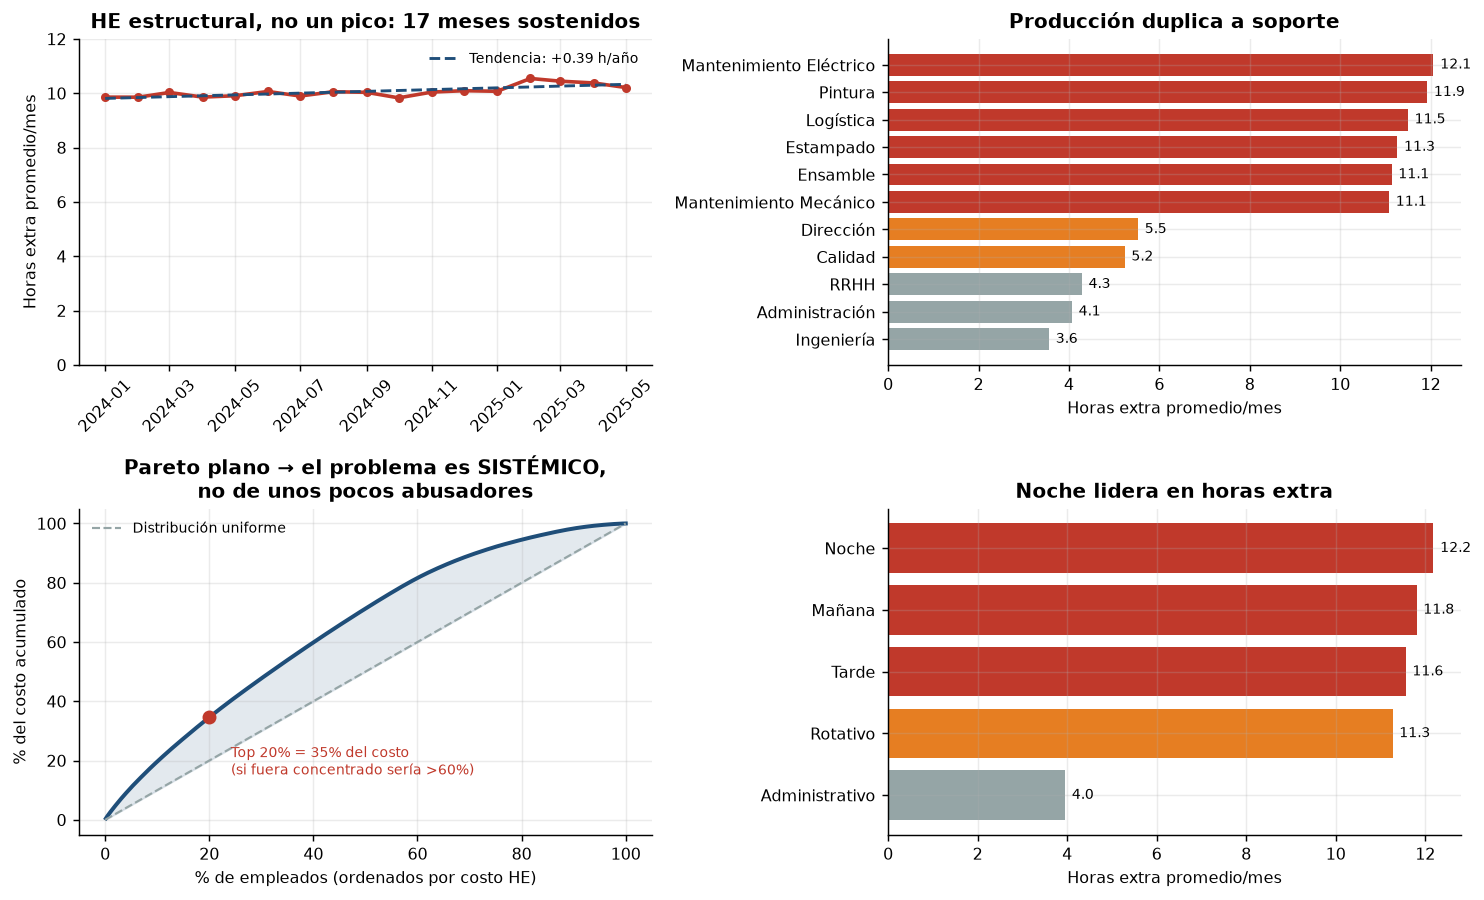

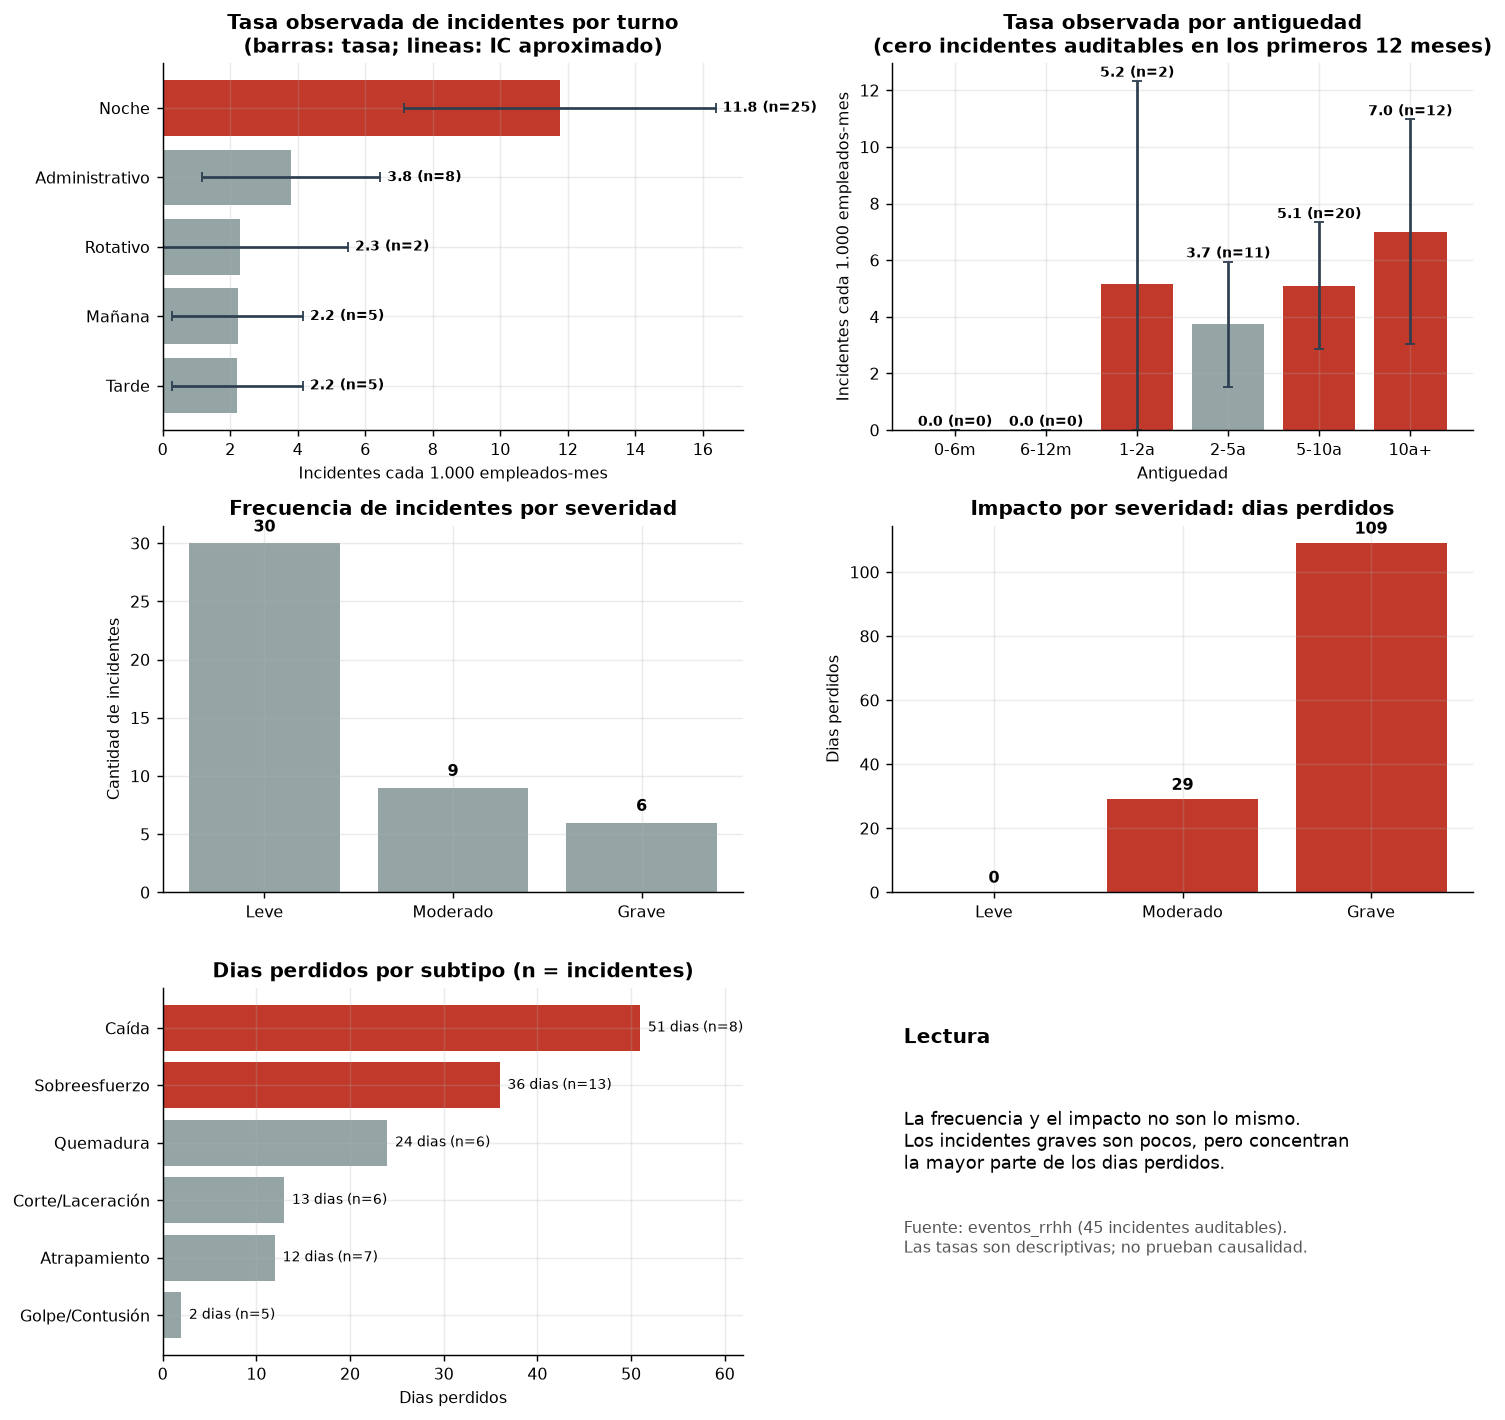

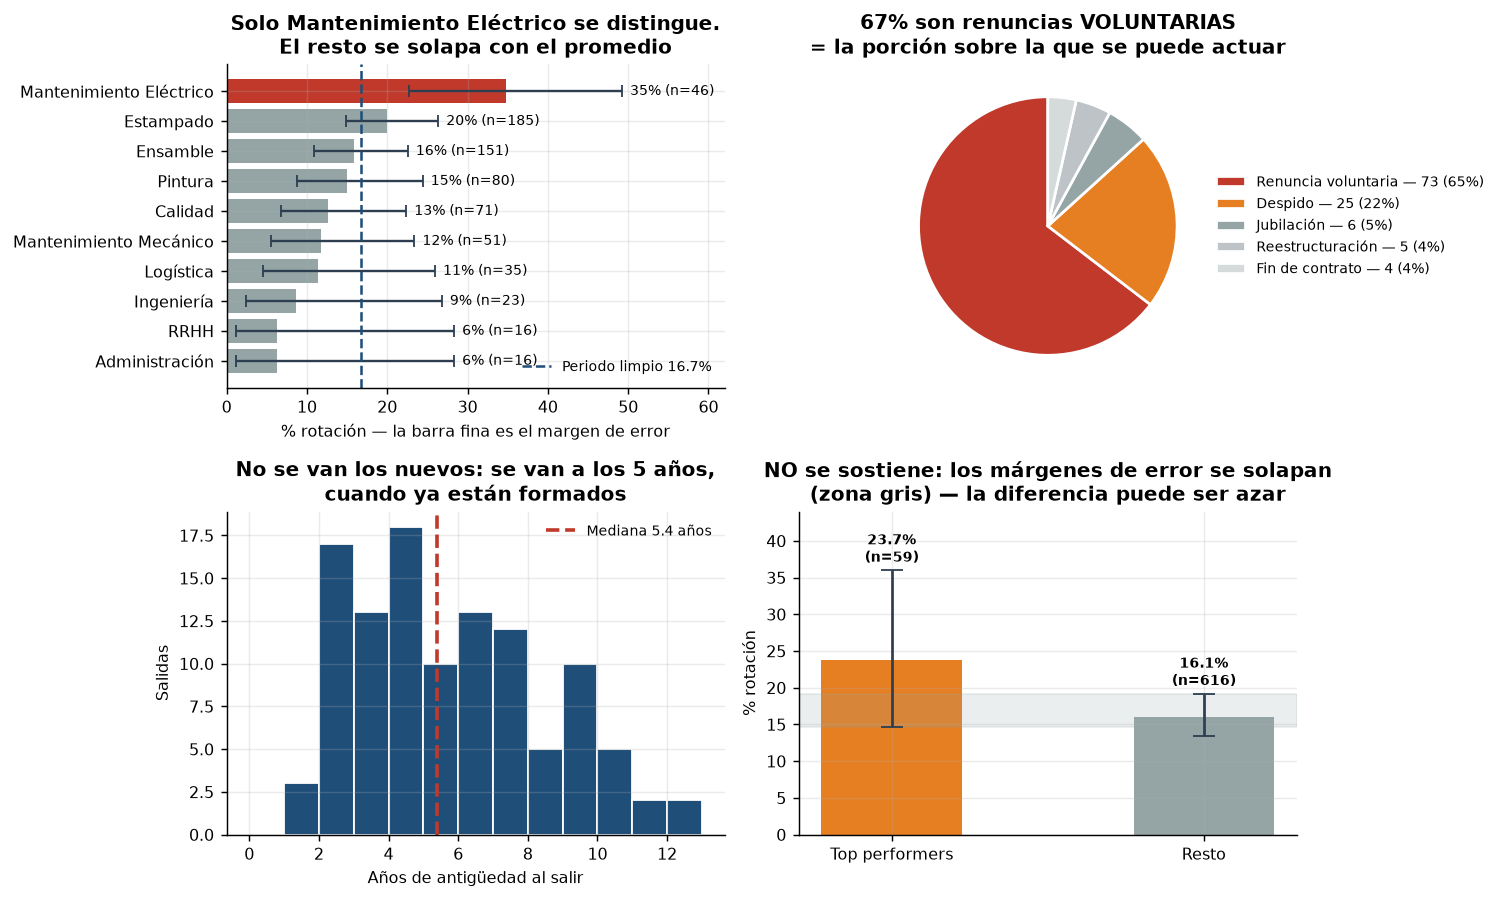

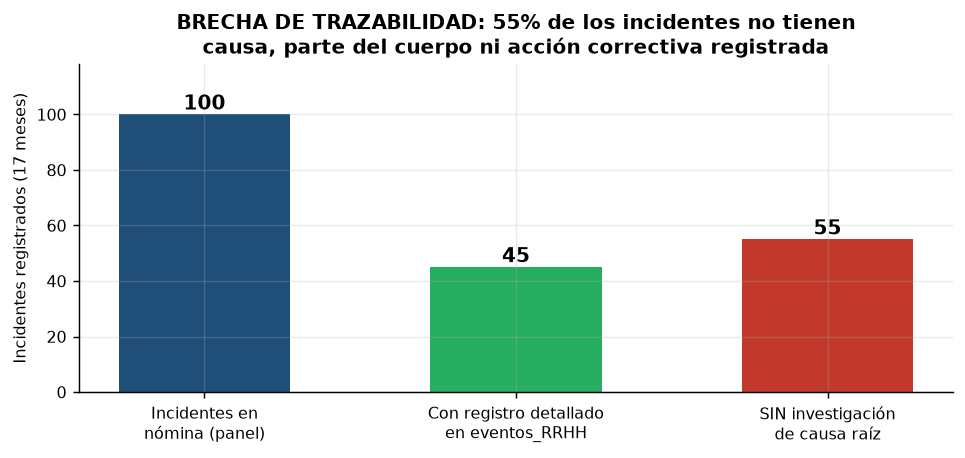

In [20]:
ejecutar_etapa("08_visualizaciones.py")
mostrar_graficos([
    "G1_piramide_etaria.png",
    "G2_genero_area_y_nivel.png",
    "G3_brecha_salarial.png",
    "G4_horas_extra.png",
    "G5_seguridad.png",
    "G6_rotacion.png",
    "G7_brecha_trazabilidad.png",
])


## 9. Sensibilidad de horas extra

Normaliza las ausencias por tiempo observado y prueba si la diferencia encontrada puede deberse al sesgo de exposición. Evita comparar empleados con distinta cantidad de meses registrados.

**Script ejecutado:** `04_scripts/10_sensibilidad_he.py`


In [18]:
ejecutar_etapa("10_sensibilidad_he.py")


### SENSIBILIDAD: cuando conviene contratar en vez de pagar horas extra?
  Recargo efectivo observado en los datos: 1.343x
  Regla: conviene contratar solo si (1 + cargas sociales) < recargo

  cargas   factor    veredicto
    15.0%   1.150    CONVIENE contratar
    25.0%   1.250    CONVIENE contratar
    30.0%   1.300    CONVIENE contratar
    33.8%   1.338    CONVIENE contratar
    40.0%   1.400    CONVIENE la hora extra
    45.0%   1.450    CONVIENE la hora extra
    50.0%   1.500    CONVIENE la hora extra

  --> PUNTO DE EQUILIBRIO: cargas sociales = 34.3%
  En Argentina las cargas patronales reales rondan 24-27% (Ley 27.541) mas ART,
  aguinaldo y vacaciones -> el costo cargado supera holgadamente el 34%.
  CONCLUSION: con estos datos, sustituir HE por dotacion NO genera ahorro.

### ENTONCES CUAL ES EL CASO REAL DE LAS HORAS EXTRA? -> fatiga y ausentismo

  Sobrecargados cronicos: 61 de 694 empleados (8.8%)
           n    he  meses_obs  ausencias_x_mes  lic_x_mes  rotacion  perf

## 10. Verificación de sobrecarga crónica y seguridad

Contrasta la señal de sobrecarga con incidentes desde más de una fuente y aplica una prueba simple. Busca diferenciar una coincidencia casual de una relación que merece atención.

**Script ejecutado:** `04_scripts/11_verif_cronicos_seguridad.py`


In [16]:
ejecutar_etapa("11_verif_cronicos_seguridad.py")


### INCIDENTES DE SOBRECARGADOS CRONICOS — dos fuentes comparadas

  FUENTE A — panel (columna incidentes_seguridad_count):
         emp_meses  inc  tasa_x1000
cronico                            
False         8725   72         8.3
True           876   27        30.8
    ratio cronico/no-cronico: 3.71x

  FUENTE B — eventos_rrhh (auditable, con causa raiz):
         emp_meses  inc  tasa_x1000
cronico                            
False         8725   43         4.9
True           876    2         2.3
    ratio cronico/no-cronico: 0.47x

  Test de proporciones (fuente auditable): z = -1.09  -> NO significativo (p > 0.05)
  n incidentes en cronicos: 2 sobre 876 empleado-mes

### VEREDICTO
  Las fuentes DISCREPAN. El 3,7x del panel no se sostiene con la fuente auditable.
  Con n tan chico no se puede afirmar que la sobrecarga cronica cause accidentes.
  Nivel de evidencia: EXPLORATORIO. Requiere validacion antes de justificar inversion.


## 11. Diagnóstico de gaps

Identifica limitaciones del dataset y separa datos medidos de supuestos. Marca qué conclusiones son sólidas y cuáles requieren validación con el cliente.

**Script ejecutado:** `04_scripts/12_diagnostico_gaps.py`


In [17]:
ejecutar_etapa("12_diagnostico_gaps.py")


GAP 1 — FALTANTES NO ALEATORIOS: mis comparaciones de scrap son validas?

  % nulos de tasa_scrap_porcentaje por categoria de collar:
                     n  pct_nulo
categoria_collar                
Blue             7,967      25.5
White            1,766      99.4

  % nulos por area:
                            n  pct_nulo
area                                   
Administración            259       100
Calidad                   976       100
Logística                 553       100
RRHH                      263       100
Ingeniería                373       100
Mantenimiento Mecánico    806       100
Mantenimiento Eléctrico   554       100
Dirección                  12       8.3
Estampado               2,531       0.2
Ensamble                2,173         0
Pintura                 1,233         0

  >> En el informe compare scrap accidentados (3,23) vs no accidentados (2,35).
            n  n_con_scrap  pct_perdido  scrap
tuvo_inc                                      
False     625     

## 12. EDA sistemático

Recorre las variables con reglas explícitas para detectar vacíos, rarezas, asimetrías y columnas poco informativas. Es una revisión ordenada para no depender solo de la intuición.

**Script ejecutado:** `04_scripts/14_eda_sistematico.py`


In [18]:
ejecutar_etapa("14_eda_sistematico.py")



TABLA empleados_mensual — 9,733 filas × 60 columnas
  numerica continua: 23 | booleana: 11 | categorica: 8 | numerica discreta: 8 | fecha: 5 | alta cardinalidad: 5

  32 alertas:
                      columna              tipo            alerta                     detalle
                       nombre alta cardinalidad ALTA CARDINALIDAD       596 valores distintos
                 fecha_salida             fecha            VACÍOS              98.6% sin dato
                motivo_salida        categorica            VACÍOS              98.6% sin dato
                         area        categorica   ETIQUETAS RARAS      1 etiquetas bajo el 1%
                      subarea        categorica   ETIQUETAS RARAS      6 etiquetas bajo el 1%
                       puesto alta cardinalidad ALTA CARDINALIDAD        52 valores distintos
             nivel_jerarquico numerica discreta    MUY ASIMÉTRICA  asimetría 2.8 — cola larga
               manager_nombre alta cardinalidad ALTA CARDINALIDAD   

## 13. Diagnóstico de fragilidad

Analiza reingresos, huecos de historial y cambios inconsistentes de antigüedad, para no inflar o distorsionar indicadores de rotación.

**Script ejecutado:** `04_scripts/15_diagnostico_fragilidad.py`


In [19]:
ejecutar_etapa("15_diagnostico_fragilidad.py")


A — DE QUE ESTA HECHO EL COSTO POR SALIDA ($5,88M)
  Reclutamiento (dato real del cliente)      $      150,000     2.6%
  Onboarding (dato real del cliente)         $       50,000     0.9%
  Vacancia (SUPUESTO NUESTRO)                $    2,908,893    49.5%
  Rampa 3 meses al 50% (SUPUESTO NUESTRO)    $    2,773,309    47.1%
  TOTAL                                      $    5,882,203

  >> 97% del costo por salida son supuestos nuestros, no datos del cliente.
  >> El business case de $92M descansa entero sobre eso.

  Sensibilidad — que pasa si los supuestos son mas conservadores:
    Solo datos reales (sin vacancia ni rampa)    $     200,000/salida -> ahorro 25% = $    3,141,176/anio
    Vacancia al 50%, rampa 2 meses al 30%        $   2,763,770/salida -> ahorro 25% = $   43,407,453/anio
    Nuestro escenario actual                     $   5,882,203/salida -> ahorro 25% = $   92,385,184/anio
    Vacancia completa, rampa 6 meses al 50%      $   8,655,512/salida -> ahorro 25% = $  135,9

C:\Users\Dell\Agus\Nivii AI\04_scripts\15_diagnostico_fragilidad.py:107: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  t = pd.concat([por_mes, hc], axis=1).dropna()


## 14. Rotación temporal 
Separa las salidas de arrastre del inicio del período y recalcula la rotación sobre un período limpio. Evita atribuir al período analizado salidas que ya venían ocurriendo antes del corte.

**Script ejecutado:** `04_scripts/16_rotacion_temporal.py`


In [20]:
ejecutar_etapa("16_rotacion_temporal.py")


DIAGNOSTICO — que pasa en enero 2024
  Salidas en 2024-01-01: 19  (un mes normal tiene ~6)
  Antiguedad media al salir: 5.2 anios
  Motivos: {'Renuncia voluntaria': np.int64(16), 'Despido': np.int64(2), 'Jubilación': np.int64(1)}

  Cuantos meses aparece cada uno en el panel antes de irse:
    {1: np.int64(19)}

  Comparado con el resto de las salidas:
    enero 2024: 1.0 meses observados en promedio
    resto     : 9.5 meses observados en promedio

  >> Salidas de enero-2024 que aparecen 1 solo mes: 19 de 19
     Son personas que ya estaban saliendo cuando empieza el archivo.
     No son rotacion generada en el periodo: son arrastre del corte.

RECALCULO — periodo limpio (desde febrero 2024)
  Todo el periodo (con enero 2024)     132 salidas / 17 meses / 565 activos ->  16.5% anual
  Periodo limpio (desde feb 2024)      113 salidas / 16 meses / 563 activos ->  15.0% anual

  >> La tasa publicada (16.5%) estaba inflada por el arrastre.
  >> Tasa corregida: 15.0% anual  (diferencia: +1.

## 15. Business case 

Presenta el impacto como un rango de escenarios y separa datos reales de supuestos. También incorpora márgenes de error para no sobreafirmar diferencias entre áreas. Esta versión reemplaza a 09_business_case.py.

**Script ejecutado:** `04_scripts/17_business_case_v2.py`


In [21]:
ejecutar_etapa("17_business_case_v2.py")


MEJORA 1 — COSTO POR SALIDA: DATO DURO vs SUPUESTO

  DATO DURO (registrado por el cliente)
    Reclutamiento              $     150,000
    Onboarding                 $      50,000
    Subtotal verificable       $     200,000

  SUPUESTOS (nuestros — el cliente no los mide)
    Salario medio del que sale $   1,901,634/mes   <- dato duro
    Dias para cubrir el puesto            47 dias  <- dato duro
    Fraccion del sueldo que se pierde durante la vacancia  <- SUPUESTO
    Meses de rampa y a que rendimiento                     <- SUPUESTO

  COSTO POR SALIDA SEGUN ESCENARIO
    conservador  $   2,836,933   (duro $200,000 + vacancia $1,495,952 + rampa $1,140,981)
                 el equipo absorbe parte del trabajo; el ingresante rinde 70% desde el mes 1
    central      $   6,044,356   (duro $200,000 + vacancia $2,991,905 + rampa $2,852,451)
                 el puesto queda descubierto; el ingresante rinde 50% durante 3 meses
    agresivo     $   8,896,808   (duro $200,000 + vacancia 

## 16. Visualizaciones para decision

Estos siete graficos conectan la evidencia con decisiones de rotacion, seguridad, sucesion, sobrecarga y business case. Se muestran directamente debajo de esta celda y tambien se guardan como archivos PNG.

**Script ejecutado:** `04_scripts/18_visualizaciones_decision.py`


  -> G8_rotacion_original_vs_limpia.png
  -> G9_rotacion_area_ic95.png
  -> G10_distribucion_horas_extra_area.png
  -> G11_incidentes_area_severidad.png
  -> G12_capacitacion_seguridad_vs_incidentes.png
  -> G13_riesgo_sucesion_por_puesto.png
  -> G14_business_case_escenarios.png
Listo. Visualizaciones de decision en: C:\Users\Dell\Agus\Nivii AI\06_resultados\Discovery\visualizaciones


C:\Users\Dell\Agus\Nivii AI\04_scripts\18_visualizaciones_decision.py:76: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(datos, tick_labels=orden, vert=False, patch_artist=True, showfliers=False)


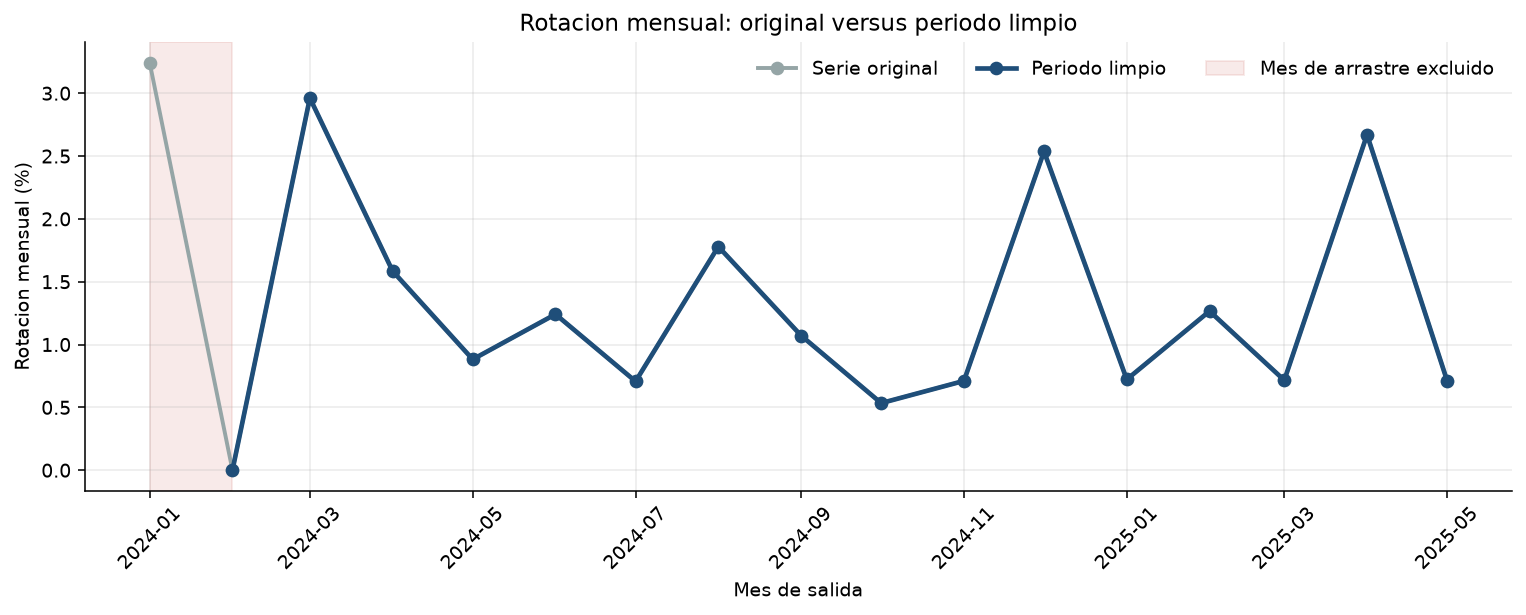

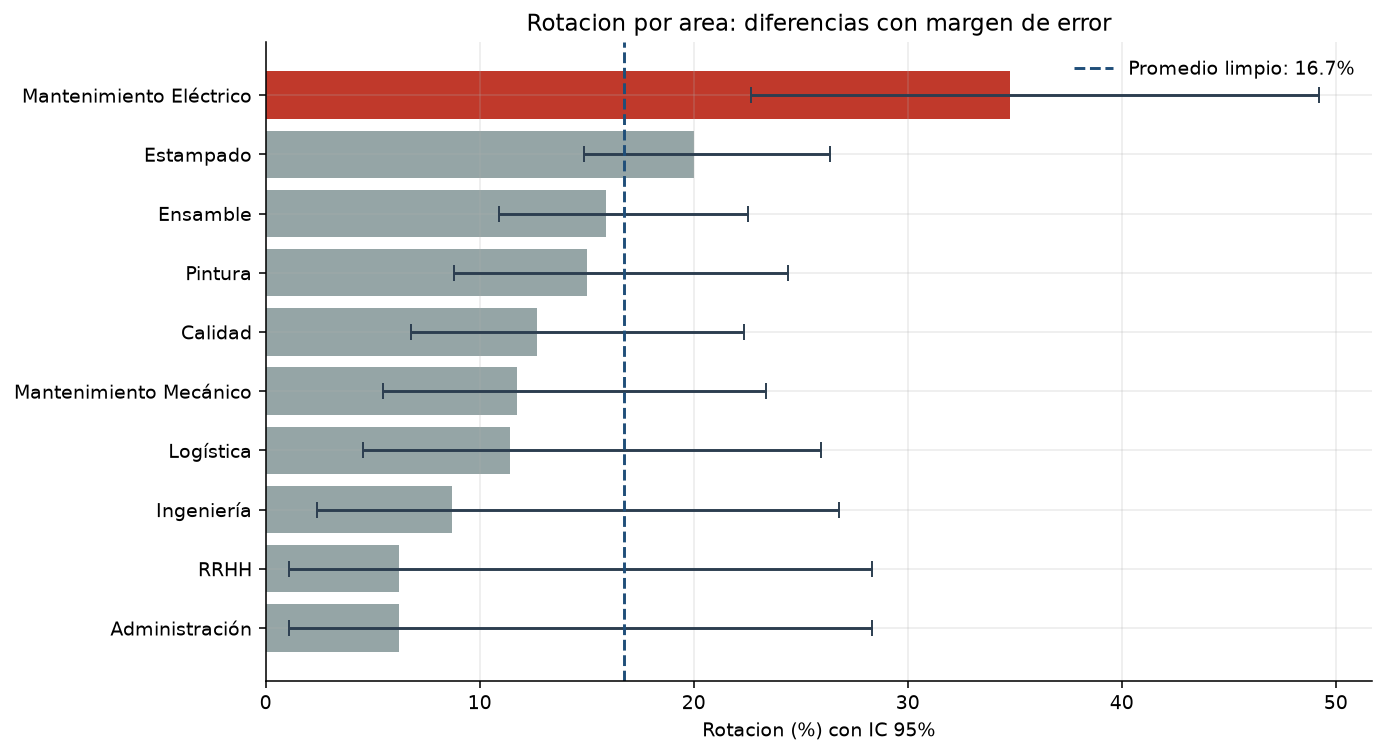

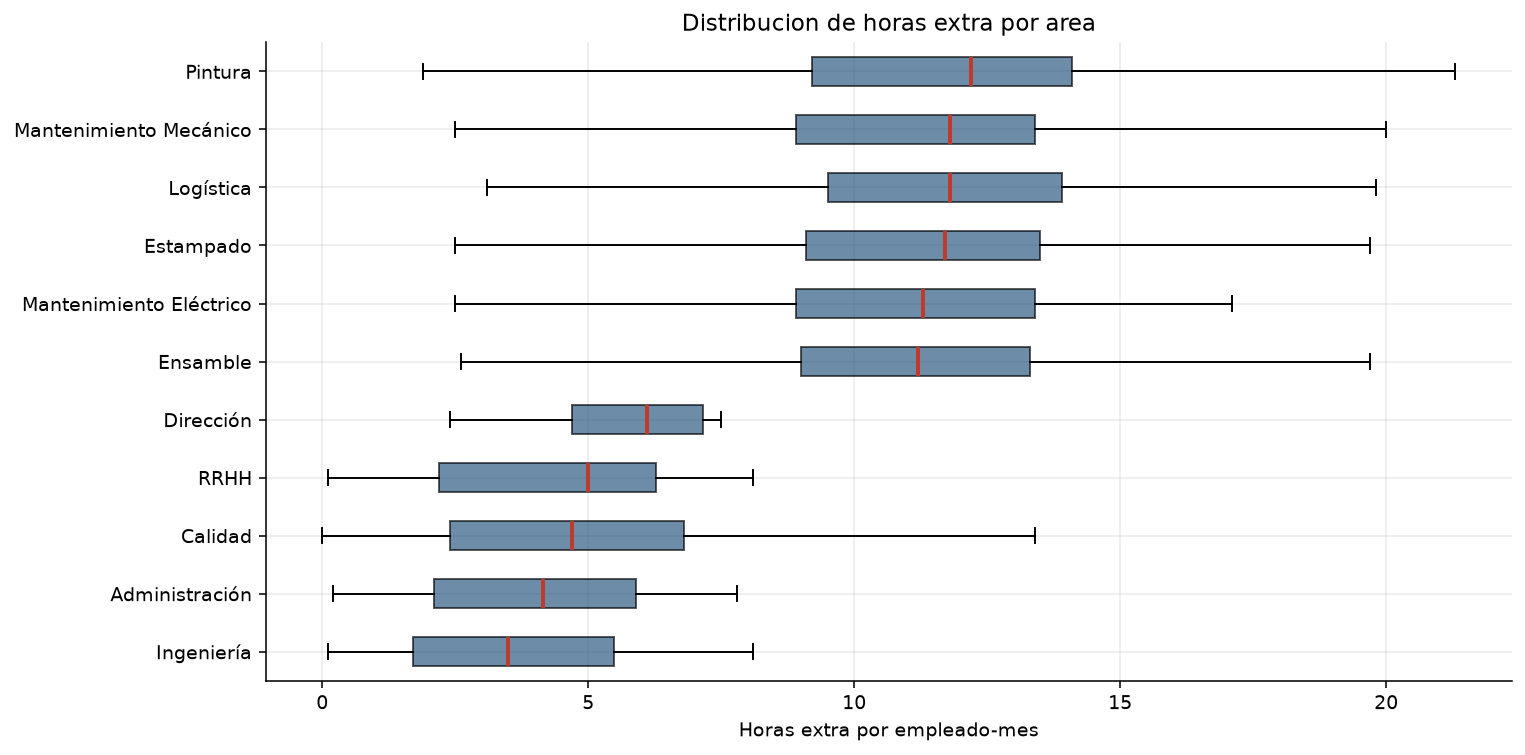

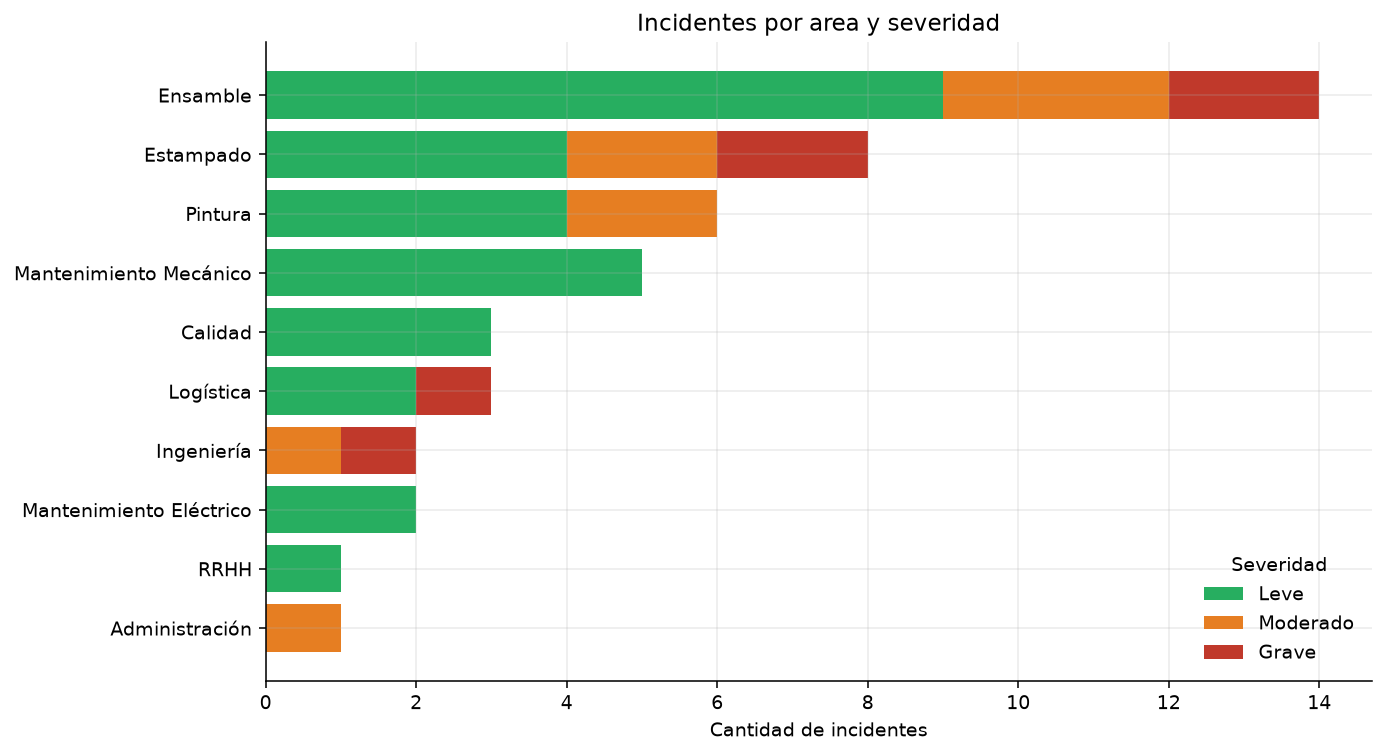

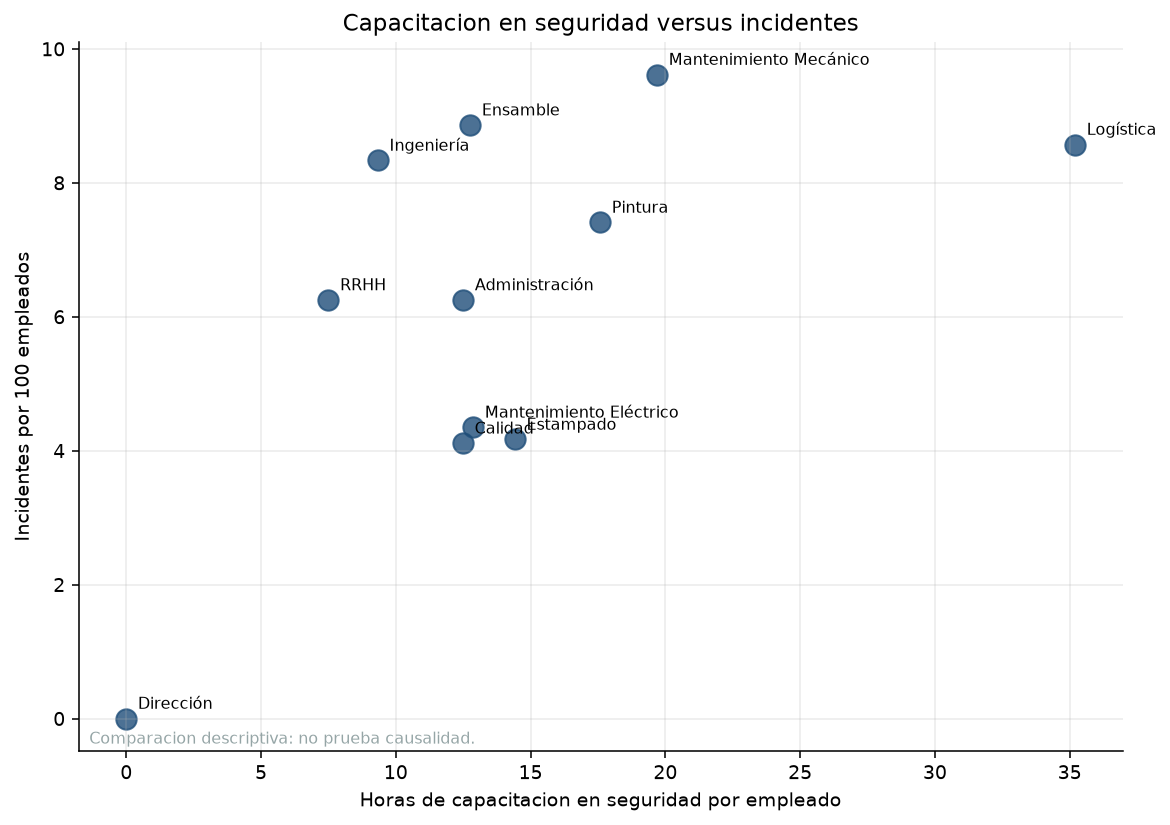

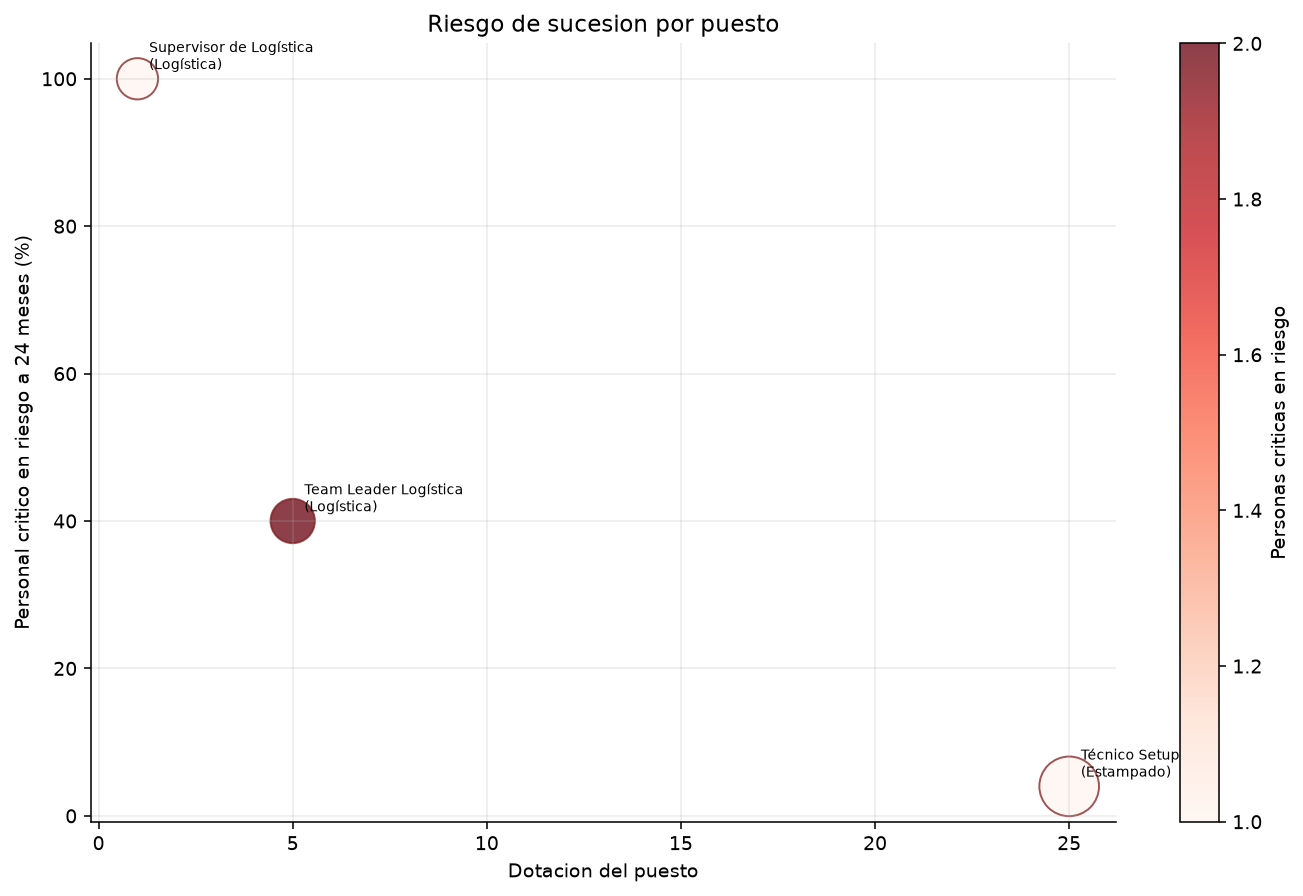

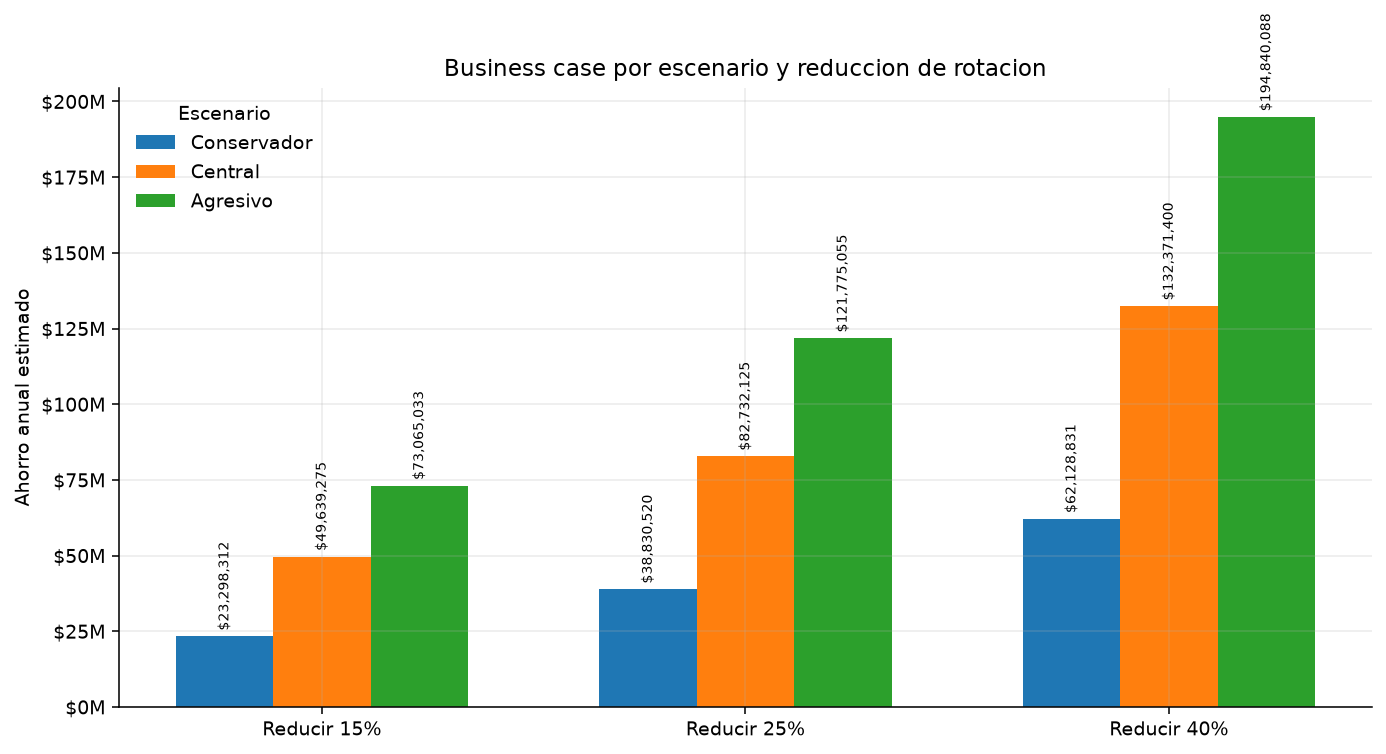

In [22]:
ejecutar_etapa("18_visualizaciones_decision.py")
mostrar_graficos([
    "G8_rotacion_original_vs_limpia.png",
    "G9_rotacion_area_ic95.png",
    "G10_distribucion_horas_extra_area.png",
    "G11_incidentes_area_severidad.png",
    "G12_capacitacion_seguridad_vs_incidentes.png",
    "G13_riesgo_sucesion_por_puesto.png",
    "G14_business_case_escenarios.png",
])


## Cierre

Se ejecutaron las 15 etapas vigentes. Las versiones mejoradas reemplazan a las versiones anteriores de limpieza y business case.


In [23]:
ETAPAS_EJECUTADAS = [
    "01_perfilado.py", "02_calidad.py", "13_limpieza_v2.py", "04_p1_p2.py",
    "05_verif_critica.py", "06_p3_p4_p5.py", "07_verif_incidentes_p5.py",
    "08_visualizaciones.py", "10_sensibilidad_he.py", "11_verif_cronicos_seguridad.py",
    "12_diagnostico_gaps.py", "14_eda_sistematico.py", "15_diagnostico_fragilidad.py",
    "16_rotacion_temporal.py", "17_business_case_v2.py",
    "18_visualizaciones_decision.py",
]

print(f"Etapas disponibles: {len(ETAPAS_EJECUTADAS)}")
print("Limpieza vigente: 13_limpieza_v2.py")
print("Business case vigente: 17_business_case_v2.py")


Etapas disponibles: 16
Limpieza vigente: 13_limpieza_v2.py
Business case vigente: 17_business_case_v2.py
